<a href="https://colab.research.google.com/github/GIRIAYUSH/playing-with-anns/blob/main/notebooks/M7_Full_Training_Loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Installs

Install what we need. We use:
- `datasets` from Hugging Face to load SST-2
- `torch` for everything neural
- No transformers — we're building bag-of-words → MLP from scratch
"""

In [1]:
!pip install datasets torch matplotlib numpy

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
import random
import os

#reproducability code
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### ABOUT THE DATASET (SST-2)
Load SST-2 from Hugging Face
"""
SST-2 (Glue benchmark version) has:
  - train: 67,349 sentences
  - validation: 872 sentences
  - test: 1,821 sentences (labels hidden — use validation as test here)

Each example is:
  { "sentence": "A stunning piece of cinema", "label": 1 }
  label 0 = negative, label 1 = positive
"""

In [22]:
dataset= load_dataset('glue','sst2')
print(f"Data set loaded sucessfully: {dataset["train"][0]}")
print(f"Class Balance (train): {Counter(dataset["train"]["label"])} ")

Data set loaded sucessfully: {'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}
Class Balance (train): Counter({1: 37569, 0: 29780}) 


### BoW Vectorizer and Vocabulary Representation

We represent text as a Bag-of-Words (BoW) vector.

Given vocabulary V = {w_1, w_2, ..., w_|V|}, a sentence maps to:
  x ∈ ℝ^|V|  where  x_i = count(w_i in sentence)

Or binary BoW:  x_i = 1 if w_i appears, 0 otherwise

This loses word order but gives a clean, dense enough signal for sentiment.
The network must learn which words are discriminative.

We build the vocabulary from training data only (no data leakage).
We keep the top MAX_VOCAB - 2 words by frequency, plus:
  <PAD> token (index 0) — unused in BoW but good practice
  <UNK> token (index 1) — for out-of-vocabulary words at inference

In [23]:
MAX_VOCAB = 10000

def simple_tokenizer(text):
  text= text.lower()
  text = re.sub(r"[^a-z\s]", " ", text)
  return text.split()

all_tokens = []
for example in dataset["train"]:
  all_tokens.extend(simple_tokenizer(example["sentence"]))

freq = Counter(all_tokens)
most_common = freq.most_common(MAX_VOCAB - 2)

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, _ in most_common:
  vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Most common words: {[w for w,_ in most_common[:10]]}")


Vocabulary size: 10000
Most common words: ['the', 'a', 'and', 'of', 'to', 's', 'is', 'that', 'in', 'it']


### BoW Vectorizer

For each sentence s, we produce a vector x ∈ ℝ^|V|:

  x_i = number of times vocab[i] appears in s  (count BoW)

Or we can normalize (TF-style):
  x_i = count(w_i) / len(s)

We'll use binary BoW for simplicity — it's more robust to length variation.

  x_i = 1  if vocab[i] ∈ s
        0  otherwise


In [24]:
def text_to_bow(text,vocab,vocab_size):
  tokens = simple_tokenizer(text)
  vec=torch.zeros(vocab_size)


  for token in tokens:
    idx = vocab.get(token,1)
    vec[idx] = 1.0
  return vec

sample= dataset["train"][0]["sentence"]
sample_vec = text_to_bow(sample,vocab,VOCAB_SIZE)

print(f"Sentence : {sample}")
print(f"BoW vector shape: {sample_vec.shape}")
print(f"Non-zero entries : {sample_vec.sum().item():.0f}")

Sentence : hide new secretions from the parental units 
BoW vector shape: torch.Size([10000])
Non-zero entries : 7


### Custom PyTorch DataLoader

PyTorch's Dataset contract requires two methods:
  __len__()      → number of samples
  __getitem__(i) → (input_tensor, label_tensor) for sample i

The DataLoader wraps this to give us:
  - Automatic batching: collects B samples → (B, vocab_size) tensor
  - Shuffling: re-orders indices each epoch (prevents order memorization)
  - Multi-worker loading (optional, set num_workers > 0 for speed)


In [25]:
class SSTDataset(Dataset):
  def __init__(self,hf_split,vocab,vocab_size):
    self.examples = hf_split
    self.vocab=vocab
    self.vocab_size=vocab_size

  def __len__(self):
    return len(self.examples)

  def __getitem__(self,idx):
    item=self.examples[idx]
    x= text_to_bow(item["sentence"],self.vocab,self.vocab_size)
    y= torch.tensor(item["label"],dtype=torch.long)
    return x,y

train_dataset = SSTDataset(dataset["train"],vocab,VOCAB_SIZE)
val_dataset   = SSTDataset(dataset["validation"], vocab, VOCAB_SIZE)

print(f"Size of training data : {len(train_dataset)}")
print(f"Size of validation data: {len(val_dataset)}")


x0,y0= train_dataset[0]
print(f"Sample dataset feature {x0} : sample label : {y0}")

Size of training data : 67349
Size of validation data: 872
Sample dataset feature tensor([0., 1., 1.,  ..., 0., 0., 0.]) : sample label : 0


### DataLoaders

BATCH_SIZE = 64: we update weights every 64 examples instead of every 1.

Why batch gradient descent?
  - Gradient over a batch is a better estimate of the true gradient than 1 sample
  - GPU/CPU utilization: matrix ops on (64, 10000) are faster than 64 × (1, 10000) loops
  - shuffle=True on training data: different ordering each epoch → generalization

One epoch = ceil(67349 / 64) = 1053 gradient update steps.


In [26]:

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val   batches per epoch: {len(val_loader)}")

# Check a batch
xb, yb = next(iter(train_loader))
print(f"Batch x: {xb.shape}, Batch y: {yb.shape}")

Train batches per epoch: 1053
Val   batches per epoch: 14
Batch x: torch.Size([64, 10000]), Batch y: torch.Size([64])


### Architecture 1: Raw PyTorch


We build a 3-layer MLP entirely from scratch using only torch.Tensor operations.
No nn.Linear, no nn.ReLU — just raw matrix math.

Architecture:
  - Input:   x ∈ ℝ^10000   (BoW vector)
  - Layer 1: h1 = ReLU(x  @ W1 + b1),   W1 ∈ ℝ^{10000×256}
  - Layer 2: h2 = ReLU(h1 @ W2 + b2),   W2 ∈ ℝ^{256×128}
  - Output:  z  = h2 @ W3 + b3,          W3 ∈ ℝ^{128×2}

The output z ∈ ℝ^2 are raw logits (unnormalized scores).
Cross-entropy loss applies softmax internally:

  P(y=k | x) = exp(z_k) / Σ_j exp(z_j)

  L = -log P(y_true | x)  = -z_{y_true} + log Σ_j exp(z_j)

Weight initialization: Kaiming (He) uniform for layers feeding into ReLU:
  W ~ Uniform(-√(6/fan_in), +√(6/fan_in))

This keeps variance of activations stable across layers — prevents vanishing gradients.


In [27]:
# code
class RawMLP:
    """
    Manual MLP: owns its Parameters, implements forward, zero_grad, step.
    """
    def __init__(self, input_dim, hidden1, hidden2, output_dim):
        # Kaiming uniform init
        def kaiming(fan_in, fan_out):
            limit = np.sqrt(6.0 / fan_in)
            return torch.FloatTensor(fan_in, fan_out).uniform_(-limit, limit).requires_grad_(True)

        self.W1 = kaiming(input_dim, hidden1)
        self.b1 = torch.zeros(hidden1, requires_grad=True)
        self.W2 = kaiming(hidden1, hidden2)
        self.b2 = torch.zeros(hidden2, requires_grad=True)
        self.W3 = kaiming(hidden2, output_dim)
        self.b3 = torch.zeros(output_dim, requires_grad=True)

        self.params = [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]

    def forward(self, x):
        h1 = torch.relu(x  @ self.W1 + self.b1)   # (B, hidden1)
        h2 = torch.relu(h1 @ self.W2 + self.b2)   # (B, hidden2)
        z  = h2 @ self.W3 + self.b3                # (B, 2)
        return z

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self, lr):
        with torch.no_grad():
            for p in self.params:
                p -= lr * p.grad

raw_model = RawMLP(VOCAB_SIZE, 256, 128, 2)
total_params = sum(p.numel() for p in raw_model.params)
print(f"Raw model parameters: {total_params:,}")

Raw model parameters: 2,593,410



### REVISED ARCHITECTURE — designed specifically for sparse BoW input.

Why we're changing things:

  Problem 1: Model too wide (256, 128 hidden units → 2.5M params for 67K samples)
    Fix: Reduce to (128, 64) → 1.3M params. Still expressive, less memorization capacity.

  Problem 2: Dropout p=0.3 is too light for sparse input.
    In BoW, a sentence of 12 words activates only 12/10000 = 0.1% of inputs.
    After W1 @ x, most neurons get small activations.
    Dropout at 0.3 still lets the model memorize rare word-label correlations.
    Fix: p=0.5 — the original Srivastava et al. (2014) recommendation for fully-connected layers.
    
    Mathematically, dropout at inference scales outputs by (1-p):
      E[dropped output] = (1-p) * h   → matches training distribution in expectation

  Problem 3: No early stopping — we run 15 epochs regardless of val loss.
    Fix: Track patience counter. Stop if val loss hasn't improved in `patience` epochs.

  Problem 4: Hard targets (0 or 1) make the model push logits to ±∞ to minimize CE.
    Label smoothing replaces hard targets with soft ones:
      y_smooth = (1 - ε) * y_one_hot + ε / K
    For ε=0.1, K=2:  [0,1] → [0.05, 0.95]
    This caps the gradient magnitude and prevents overconfident predictions.

  Architecture summary:
    Input  (10000) → Linear → ReLU → Dropout(0.5)
                  → Linear → ReLU → Dropout(0.5)  
                  → Linear (2)   ← no activation, raw logits

  Parameter count: 10000*128 + 128 + 128*64 + 64 + 64*2 + 2 = 1,289,474
  Compared to before: 2,593,410 → roughly halved.
"""

In [32]:
# code
class NeuralMLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, output_dim, dropout_p=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.net(x)

nn_model = NeuralMLP(VOCAB_SIZE, 128, 64, 2, dropout_p=0.5)

total_params = sum(p.numel() for p in nn_model.parameters())
print(f"nn.Module model parameters: {total_params:,}")
print(nn_model)

nn.Module model parameters: 1,288,514
NeuralMLP(
  (net): Sequential(
    (0): Linear(in_features=10000, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)




Optimizer:

1. LABEL SMOOTHING in the loss function
   - Standard cross-entropy:
     L_CE = -log P(y_true | x) = -z_{y_true} + log Σ_j exp(z_j)

   - With label smoothing (ε = 0.1):
     L_LS = (1 - ε) * L_CE + ε * (uniform cross-entropy over all classes)
           = (1 - ε) * L_CE + ε * log(K)    where K = num_classes

  2. Effect: the model can no longer drive loss to 0 by making logits infinitely large.
  - It forces P(correct class) → (1 - ε) = 0.9 at best, not 1.0.
   This directly caps how hard the model fits individual training examples.

   PyTorch: nn.CrossEntropyLoss(label_smoothing=0.1) — built-in since PyTorch 1.10.

2. SGD + Momentum + Weight Decay (same as before, this part was correct)
   - a. Why SGD over Adam for BoW?
   Adam maintains per-parameter adaptive rates. For sparse BoW features,
   most word dimensions are zero most of the time. Adam accumulates near-zero
   second moments for rare words, then suddenly takes a large step when that
   word appears. This causes unstable updates on infrequent but discriminative words.
   
   - b. SGD with momentum doesn't have this problem — every word gets the same lr.
   The update rule:
     v_t = γ * v_{t-1} + g_t          (velocity accumulates gradient)
     θ_t = θ_{t-1} - α * v_t          (step in velocity direction)
   
   momentum γ=0.9 means 90% of previous velocity is carried forward —
   smooths out noisy batch gradients without the adaptive instability.

3. COSINE ANNEALING scheduler
   Replaces ReduceLROnPlateau (which is reactive — only cuts lr after plateaus).
   CosineAnnealingLR smoothly decays learning rate following:
     α_t = α_min + 0.5*(α_max - α_min) * (1 + cos(π * t / T_max))
   
   At t=0:   α_t = α_max = 0.01  (full lr, aggressive early learning)
   At t=T/2: α_t = 0.005         (half lr)
   At t=T:   α_t = α_min = 1e-5  (very small steps, fine-tune near minimum)
   
   This naturally slows down training as it approaches convergence,
   reducing the chance of oscillating over the minimum.
"""

In [33]:
# code
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_nn = torch.optim.SGD(
    nn_model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-3      # stronger than before: 1e-4 → 1e-3
)

# Cosine annealing over 15 epochs, lr decays from 0.01 → 1e-5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_nn, T_max=15, eta_min=1e-5
)

LR_RAW = 0.01
print("Criterion: CrossEntropyLoss with label_smoothing=0.1")
print("Optimizer: SGD | lr=0.01 | momentum=0.9 | weight_decay=1e-3")
print("Scheduler: CosineAnnealingLR | T_max=15 | eta_min=1e-5")

Criterion: CrossEntropyLoss with label_smoothing=0.1
Optimizer: SGD | lr=0.01 | momentum=0.9 | weight_decay=1e-3
Scheduler: CosineAnnealingLR | T_max=15 | eta_min=1e-5


### Training Loop and Checkpoinint

The core loop. Four steps per batch, every epoch:

  1. FORWARD:   ŷ = model(x)                  — compute predictions
  2. LOSS:      L = criterion(ŷ, y)           — scalar loss
  3. BACKWARD:  L.backward()                  — compute ∂L/∂θ for all θ
  4. UPDATE:    optimizer.step()              — θ ← θ - α * ∂L/∂θ

Everything else (logging, checkpointing, validation) is scaffolding around this.

Validation loop:
  - torch.no_grad(): disables autograd graph construction → ~2× faster, less memory
  - model.eval(): disables dropout and uses running stats for BatchNorm
  - We track both loss and accuracy

Checkpointing:
  - After each epoch, if val_loss improved → save model weights
  - torch.save(state_dict, path): saves a dict of {param_name: tensor}
  - torch.load + model.load_state_dict: restores those weights


### Changes

Two additions to the loop:

EARLY STOPPING:
  If val_loss doesn't improve for `patience` consecutive epochs, stop training.
  This is the single most effective anti-overfitting technique — it directly
  prevents training beyond the point of best generalization.
  
  We track:
    best_val_loss   → the lowest val loss seen so far
    patience_counter → how many epochs since the last improvement
  
  When patience_counter > patience: break out of the epoch loop.
  Then we reload the best checkpoint — the weights from the actual best epoch.

SCHEDULER STEP:
  scheduler.step() must be called once per epoch (not per batch for cosine annealing).
  It updates the learning rate according to the cosine curve.
  Call it AFTER optimizer.step() to avoid the PyTorch warning about wrong order.
"""

In [35]:
# code
def train_epoch(model, loader, criterion, optimizer, is_raw=False):
    if not is_raw:
        model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        logits = model.forward(xb) if is_raw else model(xb)
        loss = criterion(logits, yb)
        if is_raw:
            model.zero_grad()
        else:
            optimizer.zero_grad()
        loss.backward()
        if not is_raw:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        if is_raw:
            model.step(LR_RAW)
        else:
            optimizer.step()
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, is_raw=False):
    if not is_raw:
        model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model.forward(xb) if is_raw else model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def full_train(model, train_loader, val_loader, criterion, optimizer,
               epochs, checkpoint_path, scheduler=None, patience=4, is_raw=False):

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, is_raw)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion, is_raw)

        # Step the scheduler once per epoch (not per batch)
        if scheduler is not None:
            scheduler.step()
            current_lr = optimizer.param_groups[0]['lr']
        else:
            current_lr = LR_RAW

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            patience_counter = 0
            if not is_raw:
                torch.save(model.state_dict(), checkpoint_path)
                flag = " ✓ saved"
            else:
                flag = " ✓ best"
        else:
            patience_counter += 1
            flag = f" (patience {patience_counter}/{patience})"

        print(f"Epoch {epoch:02d} | "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.3f} | "
              f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.3f} | "
              f"LR: {current_lr:.6f}{flag}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}. Best val loss: {best_val_loss:.4f}")
            break

    return history

### Training Raw MLP


Training the manually-built model.
SGD with fixed learning rate, no weight decay, no dropout.
This model will overfit — we'll see that in the curves.

Expected behavior:
  - Training accuracy climbs steadily
  - Validation accuracy plateaus or diverges after a point
  - The gap between train loss and val loss widens → overfitting

In [16]:
# code
EPOCHS = 15

print("Training Raw MLP (manual backprop, SGD, no regularization)")

history_raw = full_train(
    model=raw_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=None,
    epochs=EPOCHS,
    checkpoint_path="best_raw.pt",
    is_raw=True
)

Training Raw MLP (manual backprop, SGD, no regularization)
Epoch 01 | Train Loss: 0.6739  Acc: 0.577 | Val Loss: 0.6503  Acc: 0.643 ✓ best
Epoch 02 | Train Loss: 0.6264  Acc: 0.655 | Val Loss: 0.5732  Acc: 0.727 ✓ best
Epoch 03 | Train Loss: 0.5510  Acc: 0.729 | Val Loss: 0.5045  Acc: 0.784 ✓ best
Epoch 04 | Train Loss: 0.4708  Acc: 0.790 | Val Loss: 0.4635  Acc: 0.789 ✓ best
Epoch 05 | Train Loss: 0.4026  Acc: 0.834 | Val Loss: 0.4386  Acc: 0.810 ✓ best
Epoch 06 | Train Loss: 0.3500  Acc: 0.862 | Val Loss: 0.4424  Acc: 0.810
Epoch 07 | Train Loss: 0.3096  Acc: 0.878 | Val Loss: 0.4333  Acc: 0.805 ✓ best
Epoch 08 | Train Loss: 0.2782  Acc: 0.893 | Val Loss: 0.4446  Acc: 0.821
Epoch 09 | Train Loss: 0.2531  Acc: 0.904 | Val Loss: 0.4572  Acc: 0.818
Epoch 10 | Train Loss: 0.2328  Acc: 0.912 | Val Loss: 0.4524  Acc: 0.822
Epoch 11 | Train Loss: 0.2153  Acc: 0.919 | Val Loss: 0.4577  Acc: 0.822
Epoch 12 | Train Loss: 0.2005  Acc: 0.924 | Val Loss: 0.4707  Acc: 0.817
Epoch 13 | Train Loss: 

### Train the nn.Module MLP

Same architecture + data, but now with:
  - Dropout (p=0.3): randomly zeros 30% of activations per forward pass
  - BatchNorm: stabilizes training, acts as mild regularizer
  - Weight decay (L2): penalizes large weights
  - Adam: adaptive learning rates per parameter

We expect this model to:
  - Train slightly slower (regularization slows fitting)
  - Generalize better (val accuracy > raw model)
  - Show a smaller train/val gap

In [36]:


print("Training nn.Module MLP (SGD + Dropout(0.5) + LabelSmooth + Cosine LR)")


history_nn = full_train(
    model=nn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,           # CrossEntropyLoss(label_smoothing=0.1)
    optimizer=optimizer_nn,
    epochs=EPOCHS,
    checkpoint_path="best_nn.pt",
    scheduler=scheduler,
    patience=4,
    is_raw=False
)

Training nn.Module MLP (SGD + Dropout(0.5) + LabelSmooth + Cosine LR)
Epoch 01 | Train Loss: 0.6674  Acc: 0.598 | Val Loss: 0.5649  Acc: 0.757 | LR: 0.009891 ✓ saved
Epoch 02 | Train Loss: 0.5113  Acc: 0.791 | Val Loss: 0.4838  Acc: 0.806 | LR: 0.009568 ✓ saved
Epoch 03 | Train Loss: 0.4344  Acc: 0.855 | Val Loss: 0.4705  Acc: 0.812 | LR: 0.009046 ✓ saved
Epoch 04 | Train Loss: 0.4006  Acc: 0.880 | Val Loss: 0.4667  Acc: 0.823 | LR: 0.008347 ✓ saved
Epoch 05 | Train Loss: 0.3803  Acc: 0.896 | Val Loss: 0.4788  Acc: 0.813 | LR: 0.007503 (patience 1/4)
Epoch 06 | Train Loss: 0.3638  Acc: 0.908 | Val Loss: 0.4738  Acc: 0.818 | LR: 0.006549 (patience 2/4)
Epoch 07 | Train Loss: 0.3522  Acc: 0.916 | Val Loss: 0.4662  Acc: 0.829 | LR: 0.005527 ✓ saved
Epoch 08 | Train Loss: 0.3421  Acc: 0.924 | Val Loss: 0.4639  Acc: 0.827 | LR: 0.004483 ✓ saved
Epoch 09 | Train Loss: 0.3323  Acc: 0.929 | Val Loss: 0.4564  Acc: 0.823 | LR: 0.003461 ✓ saved
Epoch 10 | Train Loss: 0.3259  Acc: 0.935 | Val Loss

# Understanding Training Signals


Diagnostic plots for understanding training dynamics.

LOSS CURVES tell you:
  - Is the model learning? (train loss should decrease)
  - Is it overfitting? (val loss increases while train loss keeps decreasing)
  - Is it underfitting? (both losses high and plateau early)

ACCURACY CURVES tell you:
  - Real-world performance on held-out data
  - The gap between train and val accuracy = generalization gap

IDEAL behavior:
  - Both losses decrease and converge
  - Train acc ≈ val acc (small gap)
  - Val loss stops improving before train loss (regularization limit)



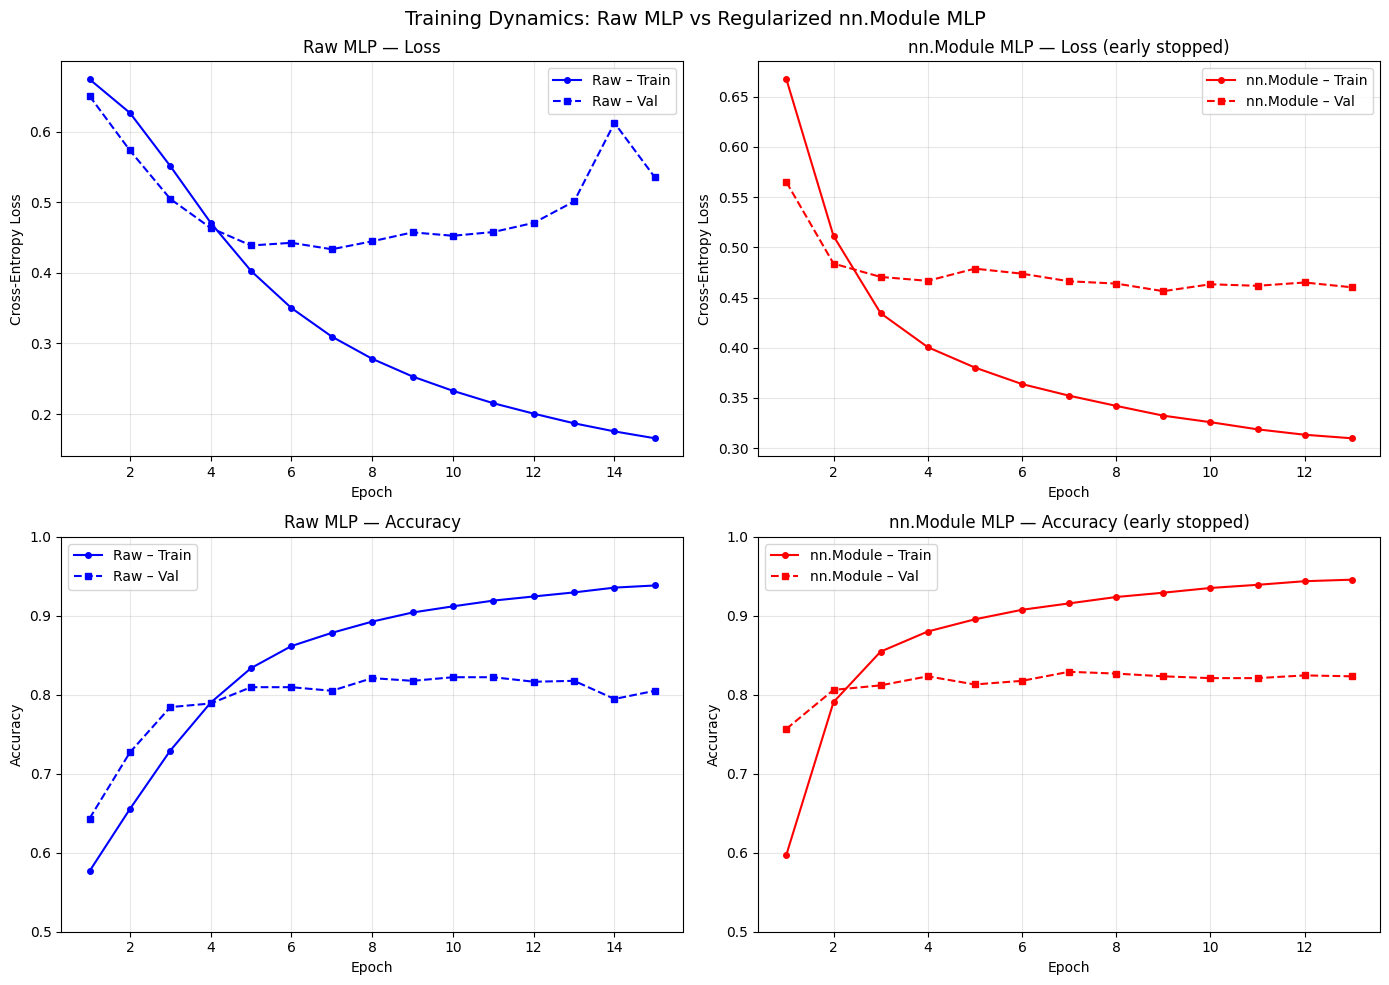

In [38]:
# code
raw_epochs = range(1, len(history_raw["train_loss"]) + 1)
nn_epochs  = range(1, len(history_nn["train_loss"])  + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training Dynamics: Raw MLP vs Regularized nn.Module MLP", fontsize=14)

ax = axes[0, 0]
ax.plot(raw_epochs, history_raw["train_loss"], "b-o", label="Raw – Train", markersize=4)
ax.plot(raw_epochs, history_raw["val_loss"],   "b--s", label="Raw – Val",   markersize=4)
ax.set_title("Raw MLP — Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(nn_epochs, history_nn["train_loss"], "r-o", label="nn.Module – Train", markersize=4)
ax.plot(nn_epochs, history_nn["val_loss"],   "r--s", label="nn.Module – Val",   markersize=4)
ax.set_title("nn.Module MLP — Loss (early stopped)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(raw_epochs, history_raw["train_acc"], "b-o", label="Raw – Train", markersize=4)
ax.plot(raw_epochs, history_raw["val_acc"],   "b--s", label="Raw – Val",   markersize=4)
ax.set_title("Raw MLP — Accuracy")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_ylim(0.5, 1.0); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(nn_epochs, history_nn["train_acc"], "r-o", label="nn.Module – Train", markersize=4)
ax.plot(nn_epochs, history_nn["val_acc"],   "r--s", label="nn.Module – Val",   markersize=4)
ax.set_title("nn.Module MLP — Accuracy (early stopped)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_ylim(0.5, 1.0); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

### Explanation:

The regularized NN showed a stable training path, compared to an unregularized raw MLP but weaker accuracy might be because of BoW and switching to word embeddings with `nn.Embeddings` might help better improve accuracy than that of BoW

In [39]:
print(history_nn)

{'train_loss': [0.6674208037031844, 0.5112644986049867, 0.43437857254234463, 0.4005982131431886, 0.38027936153881703, 0.36381701724671117, 0.35224836235487195, 0.3420915289485135, 0.33234053932435775, 0.3258577712790331, 0.3187241650328261, 0.31333663457344346, 0.3098142667092587], 'val_loss': [0.5649313079107792, 0.48383372912713146, 0.4705168593914137, 0.4666524813809526, 0.4787764281307885, 0.4737821440084265, 0.4662052436706123, 0.4639161409588035, 0.4563510368723388, 0.46320900129615716, 0.4617053478135975, 0.46499282012292004, 0.46022582272870827], 'train_acc': [0.5977074641048865, 0.7907912515404831, 0.8546971744198132, 0.8801170024796211, 0.895558954104738, 0.9076155547966562, 0.9157225793998426, 0.9237999079422115, 0.9292639831326375, 0.9352477393873703, 0.9392418595673284, 0.9438150529332284, 0.945745296886368], 'val_acc': [0.7568807339449541, 0.8061926605504587, 0.8119266055045872, 0.823394495412844, 0.8130733944954128, 0.8176605504587156, 0.8291284403669725, 0.8268348623853

In [40]:
print(history_raw)

{'train_loss': [0.6739384316447923, 0.6263620099314556, 0.5510342169711403, 0.47081036332735116, 0.40259043939904926, 0.35003007706392175, 0.30961267415488714, 0.27819229564248454, 0.2531212862332603, 0.23283989124627213, 0.21529404498925125, 0.20053979177862893, 0.18686991218325874, 0.17539867975578752, 0.16567177345964093], 'val_loss': [0.650298313810191, 0.5731538468544636, 0.504539816204561, 0.463460174722409, 0.4386365818321158, 0.44242864464401105, 0.43329187380064516, 0.44455050929970696, 0.4572141504068987, 0.45237847424428396, 0.45768922731417033, 0.4706505701082562, 0.500951352469418, 0.6121002375532728, 0.5350724918033005], 'train_acc': [0.5766975010764822, 0.6554069102733523, 0.7293946458002346, 0.7900488500200449, 0.8337911476042703, 0.8617054447727509, 0.8784094789826129, 0.8926635881750286, 0.9042005078026399, 0.9119808757368335, 0.9192415626067202, 0.9244977653714235, 0.9296351838928566, 0.9356931802996332, 0.9384103698644375], 'val_acc': [0.643348623853211, 0.727064220

In [41]:
"""
LOSS LANDSCAPE VISUALIZATION

We cannot plot the full 2.5M-parameter loss surface — it lives in a space
no human can visualize. Instead we use the filter normalization method
(Li et al., 2018 "Visualizing the Loss Landscape of Neural Nets"):

  1. Take trained weights θ* (our best checkpoint)
  2. Pick two random directions δ, η in parameter space,
     each normalized to the same scale as θ* (filter normalization)
  3. Evaluate loss on a grid:
       L(α, β) = Loss(θ* + α·δ + β·η)
  4. Plot L as a 3D surface and contour map

Filter normalization — why it matters:
  Raw random directions have different scales in different layers.
  A step of size 1 in W1 (10000×128) means something very different
  from a step of size 1 in W3 (64×2).
  We normalize each filter (row of weight matrix) to match the
  corresponding filter's norm in θ*:
    d_normalized[i] = d[i] * (||θ*[i]|| / ||d[i]||)
  This makes α and β comparable across layers.

Gradient descent path:
  We also record the (α, β) coordinates of the model at each training epoch
  by projecting the weight vector onto the two directions:
    α_t = (θ_t - θ*) · δ / ||δ||²
    β_t = (θ_t - θ*) · η / ||η||²
  This shows the actual path taken through the loss landscape.

Note: we use the nn.Module model since we have its full checkpoint history.
We save weights at each epoch during a short retrain for this purpose.
"""

# --- Step 1: Retrain nn.Module saving weights every epoch ---
landscape_model = NeuralMLP(VOCAB_SIZE, 128, 64, 2, dropout_p=0.5)
landscape_opt = torch.optim.SGD(
    landscape_model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-3
)
landscape_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    landscape_opt, T_max=10, eta_min=1e-5
)

epoch_weights = []   # store flat weight vector at each epoch

print("Collecting weight snapshots for landscape visualization...")
for epoch in range(1, 11):
    landscape_model.train()
    for xb, yb in train_loader:
        logits = landscape_model(xb)
        loss = criterion(logits, yb)
        landscape_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(landscape_model.parameters(), 1.0)
        landscape_opt.step()
    landscape_sched.step()

    # Save flat parameter snapshot
    flat = torch.cat([p.data.view(-1) for p in landscape_model.parameters()])
    epoch_weights.append(flat.clone())

    vl, va = eval_epoch(landscape_model, val_loader, criterion)
    print(f"  Epoch {epoch:02d} | Val Loss: {vl:.4f} | Val Acc: {va:.3f}")

theta_star = epoch_weights[-1]   # final weights = our "minimum"
n_params = theta_star.numel()
print(f"\nWeight vector dimension: {n_params:,}")

  Epoch 01 | Val Loss: 0.5899 | Val Acc: 0.742
  Epoch 02 | Val Loss: 0.4766 | Val Acc: 0.829
  Epoch 03 | Val Loss: 0.4916 | Val Acc: 0.802
  Epoch 04 | Val Loss: 0.4835 | Val Acc: 0.808
  Epoch 05 | Val Loss: 0.4680 | Val Acc: 0.827
  Epoch 06 | Val Loss: 0.4670 | Val Acc: 0.814
  Epoch 07 | Val Loss: 0.4638 | Val Acc: 0.822
  Epoch 08 | Val Loss: 0.4635 | Val Acc: 0.821
  Epoch 09 | Val Loss: 0.4663 | Val Acc: 0.820
  Epoch 10 | Val Loss: 0.4660 | Val Acc: 0.818

Weight vector dimension: 1,288,514


In [42]:
def filter_normalize(direction_params, reference_params):
    normalized = []
    for d, ref in zip(direction_params, reference_params):
        if ref.dim() >= 2:
            # Normalize each filter (row) independently
            d_norms   = d.view(d.size(0), -1).norm(dim=1, keepdim=True) + 1e-10
            ref_norms = ref.view(ref.size(0), -1).norm(dim=1, keepdim=True)
            scale = ref_norms / d_norms
            normalized.append((d.view(d.size(0), -1) * scale).view(d.shape))
        else:
            # Bias: normalize as a flat vector
            scale = ref.norm() / (d.norm() + 1e-10)
            normalized.append(d * scale)
    return normalized

torch.manual_seed(42)
ref_params = [p.data for p in landscape_model.parameters()]

raw_d1 = [torch.randn_like(p) for p in ref_params]
raw_d2 = [torch.randn_like(p) for p in ref_params]

d1_params = filter_normalize(raw_d1, ref_params)
d2_params = filter_normalize(raw_d2, ref_params)

# Flatten directions to vectors for projection math later
d1_flat = torch.cat([d.view(-1) for d in d1_params])
d2_flat = torch.cat([d.view(-1) for d in d2_params])

def set_params_from_flat(model, flat_vec):
    offset = 0
    for p in model.parameters():
        numel = p.numel()
        p.data.copy_(flat_vec[offset:offset + numel].view(p.shape))
        offset += numel

def set_params_from_direction(model, theta, alpha, d1_flat, beta, d2_flat):
    perturbed = theta + alpha * d1_flat + beta * d2_flat
    set_params_from_flat(model, perturbed)

# --- Evaluate loss on a grid of (alpha, beta) values ---
GRID = 35
alphas = torch.linspace(-1.0, 1.0, GRID)
betas  = torch.linspace(-1.0, 1.0, GRID)
Z = np.zeros((GRID, GRID))

print("Computing loss surface (this takes ~2-3 minutes)...")
for i, a in enumerate(alphas):
    for j, b in enumerate(betas):
        set_params_from_direction(landscape_model, theta_star, a, d1_flat, b, d2_flat)
        landscape_model.eval()
        batch_losses = []
        with torch.no_grad():
            # Sample 10 batches for speed — full dataset is too slow on CPU
            for k, (xb, yb) in enumerate(val_loader):
                loss = criterion(landscape_model(xb), yb)
                batch_losses.append(loss.item())
                if k >= 9:
                    break
        Z[i, j] = np.mean(batch_losses)
    if (i + 1) % 5 == 0:
        print(f"  Row {i+1}/{GRID} done...")

# Restore trained weights
set_params_from_flat(landscape_model, theta_star)
print("Loss surface computed.")

Computing loss surface (this takes ~2-3 minutes)...
  Row 5/35 done...
  Row 10/35 done...
  Row 15/35 done...
  Row 20/35 done...
  Row 25/35 done...
  Row 30/35 done...
  Row 35/35 done...
Loss surface computed.


### Projecting Training Path to Loss Surface

In [43]:
path_alphas = []
path_betas  = []

d1_norm_sq = (d1_flat ** 2).sum().item()
d2_norm_sq = (d2_flat ** 2).sum().item()

for w in epoch_weights:
    delta = w - theta_star
    a = (delta * d1_flat).sum().item() / d1_norm_sq
    b = (delta * d2_flat).sum().item() / d2_norm_sq
    path_alphas.append(a)
    path_betas.append(b)

print("Gradient descent path coordinates (α, β) per epoch:")
for ep, (a, b) in enumerate(zip(path_alphas, path_betas), 1):
    print(f"  Epoch {ep:02d}: α={a:+.4f}  β={b:+.4f}")

Gradient descent path coordinates (α, β) per epoch:
  Epoch 01: α=-0.0066  β=-0.0001
  Epoch 02: α=-0.0030  β=-0.0009
  Epoch 03: α=-0.0022  β=-0.0009
  Epoch 04: α=-0.0013  β=-0.0004
  Epoch 05: α=-0.0007  β=-0.0004
  Epoch 06: α=-0.0003  β=-0.0001
  Epoch 07: α=-0.0003  β=-0.0001
  Epoch 08: α=-0.0001  β=-0.0000
  Epoch 09: α=-0.0000  β=-0.0000
  Epoch 10: α=+0.0000  β=+0.0000


### Plot 3D Surface and Contour Path

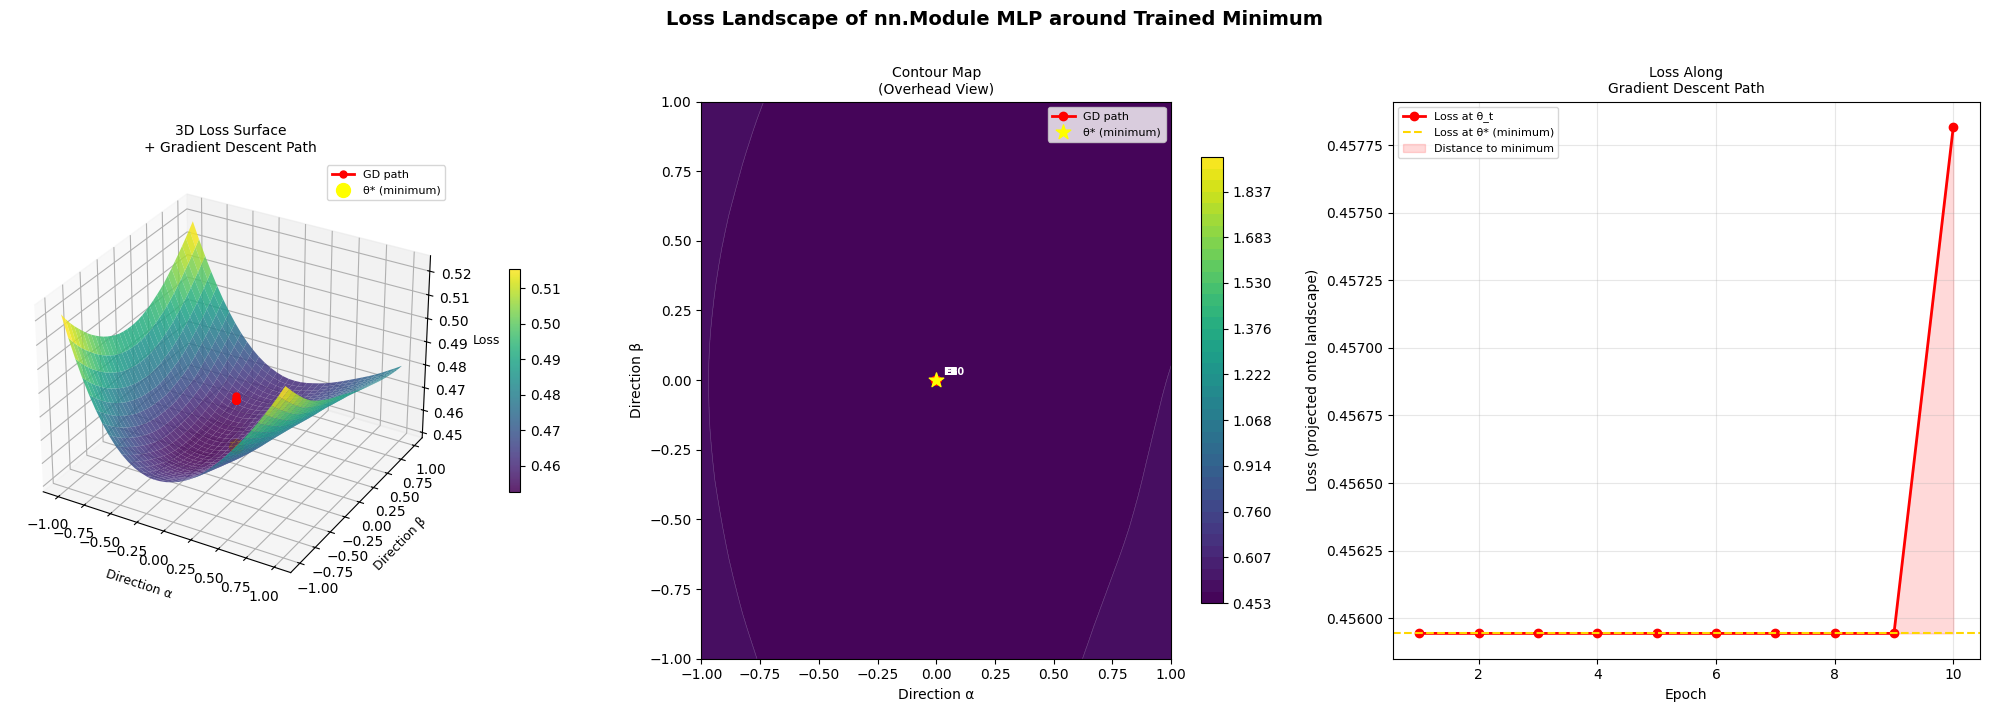

In [44]:
from mpl_toolkits.mplot3d import Axes3D

A, B = np.meshgrid(alphas.numpy(), betas.numpy())
Z_plot = Z.T   # transpose so axes align correctly

fig = plt.figure(figsize=(20, 7))
fig.suptitle("Loss Landscape of nn.Module MLP around Trained Minimum",
             fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: 3D Surface ──────────────────────────────────────────────
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(A, B, Z_plot, cmap='viridis', alpha=0.85,
                         linewidth=0, antialiased=True)
# Overlay path on 3D surface
if path_alphas:
    path_z = []
    for a, b in zip(path_alphas, path_betas):
        # find nearest grid point for height
        ai = int(np.clip(np.searchsorted(alphas.numpy(), a), 0, GRID-1))
        bi = int(np.clip(np.searchsorted(betas.numpy(), b),  0, GRID-1))
        path_z.append(Z[ai, bi] + 0.02)  # slight offset above surface
    ax1.plot(path_alphas, path_betas, path_z,
             'r-o', markersize=5, linewidth=2, zorder=10, label='GD path')
    ax1.scatter([0], [0], [Z[GRID//2, GRID//2]],
                color='yellow', s=100, zorder=11, label='θ* (minimum)')

ax1.set_xlabel('Direction α', fontsize=9, labelpad=6)
ax1.set_ylabel('Direction β', fontsize=9, labelpad=6)
ax1.set_zlabel('Loss',        fontsize=9, labelpad=6)
ax1.set_title('3D Loss Surface\n+ Gradient Descent Path', fontsize=10)
ax1.view_init(elev=30, azim=-60)
fig.colorbar(surf, ax=ax1, shrink=0.4, pad=0.1)
ax1.legend(fontsize=8)

# ── Plot 2: Contour Map (overhead view) ────────────────────────────
ax2 = fig.add_subplot(132)
levels = np.linspace(Z_plot.min(), Z_plot.min() + 1.5, 40)
cp = ax2.contourf(A, B, Z_plot, levels=levels, cmap='viridis')
ax2.contour( A, B, Z_plot, levels=levels, colors='white',
             alpha=0.25, linewidths=0.4)

if path_alphas:
    ax2.plot(path_alphas, path_betas, 'r-o', markersize=6,
             linewidth=2, zorder=5, label='GD path')
    for i, (a, b) in enumerate(zip(path_alphas, path_betas)):
        ax2.annotate(f'E{i+1}', (a, b), textcoords="offset points",
                     xytext=(6, 4), fontsize=7, color='white', fontweight='bold')
    ax2.scatter([0], [0], color='yellow', s=120, zorder=6,
                marker='*', label='θ* (minimum)')

ax2.set_xlabel('Direction α'); ax2.set_ylabel('Direction β')
ax2.set_title('Contour Map\n(Overhead View)', fontsize=10)
ax2.legend(fontsize=8, loc='upper right')
fig.colorbar(cp, ax=ax2, shrink=0.8)

# ── Plot 3: Loss along the training path ───────────────────────────
ax3 = fig.add_subplot(133)
ep_range = range(1, len(epoch_weights) + 1)
path_losses = []
for a, b in zip(path_alphas, path_betas):
    ai = int(np.clip(np.searchsorted(alphas.numpy(), a), 0, GRID-1))
    bi = int(np.clip(np.searchsorted(betas.numpy(), b),  0, GRID-1))
    path_losses.append(Z[ai, bi])

ax3.plot(ep_range, path_losses, 'r-o', markersize=6, linewidth=2, label='Loss at θ_t')
ax3.axhline(y=Z[GRID//2, GRID//2], color='gold', linestyle='--',
            linewidth=1.5, label='Loss at θ* (minimum)')
ax3.fill_between(ep_range, path_losses, Z[GRID//2, GRID//2],
                 alpha=0.15, color='red', label='Distance to minimum')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss (projected onto landscape)')
ax3.set_title('Loss Along\nGradient Descent Path', fontsize=10)
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_landscape_3d.png", dpi=150, bbox_inches='tight')
plt.show()

### Gradient Flow

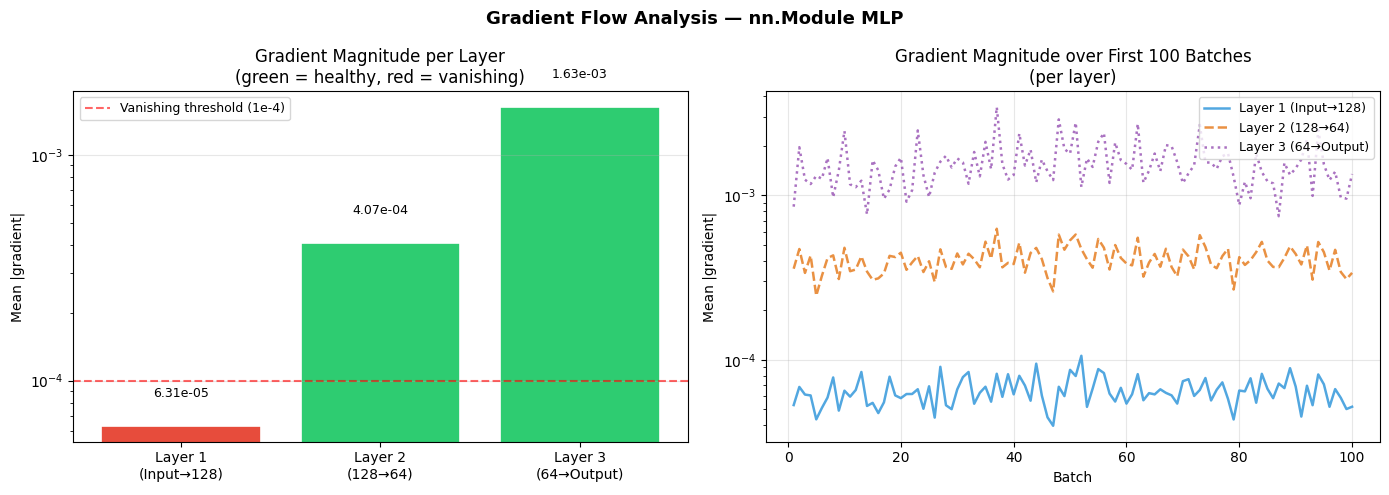

In [45]:
def get_gradient_norms(model, loader, criterion, n_batches=50):
    model.train()

    # Accumulate gradient norms over n_batches
    grad_accum = {name: [] for name, _ in model.named_parameters()
                  if 'weight' in name}

    for k, (xb, yb) in enumerate(loader):
        model.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()

        for name, param in model.named_parameters():
            if 'weight' in name and param.grad is not None:
                grad_accum[name].append(param.grad.abs().mean().item())

        if k >= n_batches - 1:
            break

    return {name: np.mean(vals) for name, vals in grad_accum.items()}


# Load best checkpoint for clean gradient analysis
nn_model.load_state_dict(torch.load("best_nn.pt"))
grad_norms = get_gradient_norms(nn_model, train_loader, criterion)

layer_names = list(grad_norms.keys())
norms       = list(grad_norms.values())
# Clean up names for display: "net.0.weight" → "Layer 1\n(10K→128)"
display_names = ["Layer 1\n(Input→128)", "Layer 2\n(128→64)", "Layer 3\n(64→Output)"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gradient Flow Analysis — nn.Module MLP", fontsize=13, fontweight='bold')

# Bar chart of gradient norms
colors = ['#2ecc71' if n > 1e-4 else '#e74c3c' for n in norms]
bars = ax1.bar(display_names, norms, color=colors, edgecolor='white', linewidth=1.2)
ax1.set_ylabel("Mean |gradient|")
ax1.set_title("Gradient Magnitude per Layer\n(green = healthy, red = vanishing)")
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, norms):
    ax1.text(bar.get_x() + bar.get_width()/2, val * 1.3,
             f'{val:.2e}', ha='center', va='bottom', fontsize=9)

# Add threshold line
ax1.axhline(y=1e-4, color='red', linestyle='--', alpha=0.6, label='Vanishing threshold (1e-4)')
ax1.legend(fontsize=9)

# Gradient norm evolution over batches (first 50 batches of one epoch)
nn_model.train()
batch_grad_history = {name: [] for name, _ in nn_model.named_parameters()
                      if 'weight' in name}

for k, (xb, yb) in enumerate(train_loader):
    nn_model.zero_grad()
    loss = criterion(nn_model(xb), yb)
    loss.backward()
    for name, param in nn_model.named_parameters():
        if 'weight' in name and param.grad is not None:
            batch_grad_history[name].append(param.grad.abs().mean().item())
    if k >= 99:
        break

batch_range = range(1, 101)
line_styles = ['-', '--', ':']
layer_colors = ['#3498db', '#e67e22', '#9b59b6']

for (name, vals), ls, lc, dn in zip(batch_grad_history.items(),
                                      line_styles, layer_colors, display_names):
    ax2.plot(batch_range, vals, ls, color=lc, linewidth=1.8,
             alpha=0.85, label=dn.replace('\n', ' '))

ax2.set_xlabel("Batch")
ax2.set_ylabel("Mean |gradient|")
ax2.set_title("Gradient Magnitude over First 100 Batches\n(per layer)")
ax2.set_yscale('log')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_flow.png", dpi=150)
plt.show()

### Final Inferencing

In [48]:
"""
END-TO-END INFERENCE

At inference time, the pipeline is:
  raw text → tokenize → BoW vector → model (eval mode) → logits → softmax → label

model.eval() is not optional here. Without it:
  - Dropout is still active → random neurons dropped → non-deterministic predictions
  - If BatchNorm were present: uses batch stats instead of running stats (wrong for batch=1)

torch.no_grad() is also critical:
  - Disables autograd graph construction
  - ~2x faster inference, half the memory
  - Prevents accidental gradient accumulation

Confidence = max(softmax(logits)) = P(predicted_class | x)
A confidence near 0.5 means the model is uncertain — the sentence likely
contains mixed signals (negation, sarcasm) that BoW can't resolve.
"""

nn_model.load_state_dict(torch.load("best_nn.pt"))
nn_model.eval()

def predict(text, model, vocab, vocab_size):
    with torch.no_grad():
        x = text_to_bow(text, vocab, vocab_size).unsqueeze(0)
        logits = model(x)
        probs  = F.softmax(logits, dim=1).squeeze()
        pred   = logits.argmax(dim=1).item()
    return ("POSITIVE" if pred == 1 else "NEGATIVE"), probs[pred].item(), probs.tolist()

test_sentences = [
    ("This movie was absolutely wonderful and deeply moving.", "POS"),
    ("Terrible film. Boring, slow, and a complete waste of time.", "NEG"),
    ("A masterpiece of modern cinema.",                          "POS"),
    ("I fell asleep halfway through. Dreadful.",                 "NEG"),
    ("Not bad at all — surprisingly enjoyable.",                 "POS"),  # negation test
    ("It wasn't terrible but it wasn't good either.",            "NEU"),  # ambiguous
    ("The film is not bad.",                                     "POS"),  # BoW weakness
    ("Bad, not good. Terrible, not wonderful.",                  "NEG"),  # BoW weakness
]

print(f"\n{'Sentence':<50} {'True':>5} {'Pred':>10} {'Conf':>7}  {'P(neg)':>8} {'P(pos)':>8}")

correct = 0
for sentence, true_label in test_sentences:
    label, conf, probs = predict(sentence, nn_model, vocab, VOCAB_SIZE)
    match = "✓" if label[0] == true_label[0] else "✗"
    if true_label != "NEU" and label[0] == true_label[0]:
        correct += 1
    print(f"{sentence[:48]:<50} {true_label:>5} {label:>10} {conf:>7.3f}  "
          f"{probs[0]:>8.3f} {probs[1]:>8.3f}  {match}")


print(f"\nAccuracy on test sentences (excl. ambiguous): {correct}/7")
print("\nNote: 'Not bad' and negation sentences reveal BoW's core limitation —")



Sentence                                            True       Pred    Conf    P(neg)   P(pos)
This movie was absolutely wonderful and deeply m     POS   POSITIVE   0.958     0.042    0.958  ✓
Terrible film. Boring, slow, and a complete wast     NEG   NEGATIVE   0.992     0.992    0.008  ✓
A masterpiece of modern cinema.                      POS   POSITIVE   0.932     0.068    0.932  ✓
I fell asleep halfway through. Dreadful.             NEG   NEGATIVE   0.977     0.977    0.023  ✓
Not bad at all — surprisingly enjoyable.             POS   NEGATIVE   0.765     0.765    0.235  ✗
It wasn't terrible but it wasn't good either.        NEU   NEGATIVE   0.735     0.735    0.265  ✓
The film is not bad.                                 POS   NEGATIVE   0.887     0.887    0.113  ✗
Bad, not good. Terrible, not wonderful.              NEG   NEGATIVE   0.649     0.649    0.351  ✓

Accuracy on test sentences (excl. ambiguous): 5/7

Note: 'Not bad' and negation sentences reveal BoW's core limitation 